## Imports

In [ ]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

## Connexion à PostgreSQL

In [2]:
load_dotenv(dotenv_path="../../.env")

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="datapulse_db",
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD")
)

query = """
SELECT t.filename, t.source_dataset, t.size_bytes, t.duration_seconds, i.label_name as instrument
FROM audio_tracks t
JOIN instruments i ON t.instrument_id = i.id;
"""
df = pd.read_sql(query, conn)
conn.close()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_29832\1828987568.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## Nettoyage des données

In [3]:
df = df.dropna(subset=['duration_seconds'])
df = df[df['instrument'] != 'unknown']
df['format'] = df['filename'].apply(lambda x: x.split('.')[-1].upper())
print(df.head())

                              filename      source_dataset  size_bytes  \
0  banjo_A3_very-long_forte_normal.mp3  philharmonia_scrap       43779   
1  banjo_A3_very-long_piano_normal.mp3  philharmonia_scrap       44093   
2  banjo_A4_very-long_forte_normal.mp3  philharmonia_scrap       47855   
3  banjo_A4_very-long_piano_normal.mp3  philharmonia_scrap       40018   
4  banjo_A5_very-long_forte_normal.mp3  philharmonia_scrap       48481   

   duration_seconds instrument format  
0          3.653719      banjo    MP3  
1          3.679909      banjo    MP3  
2          3.993878      banjo    MP3  
3          3.339818      banjo    MP3  
4          4.046123      banjo    MP3  


## Choix des features et séparation des données Train/Test

In [4]:
X = df[['source_dataset', 'size_bytes', 'duration_seconds', 'format']]
X['bytes_per_second'] = X['size_bytes'] / (X['duration_seconds'] + 0.001)
y = df['instrument']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} pistes")
print(f"Taille du jeu de test : {X_test.shape[0]} pistes")

Taille du jeu d'entraînement : 18026 pistes
Taille du jeu de test : 4507 pistes


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_29832\673777829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['bytes_per_second'] = X['size_bytes'] / (X['duration_seconds'] + 0.001)


## Pipeline de préparation et Modélisation

In [5]:
categorical_features = ['source_dataset', 'format']
numerical_features = ['size_bytes', 'duration_seconds', 'bytes_per_second']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators= 200,
        random_state= 42, 
        max_depth= 15,
        class_weight='balanced'
    ))
])

### Entraînement du modèle

In [6]:
print("Entraînement du modèle de classification en cours ...")
model_pipeline.fit(X_train, y_train)
print("Modèle entraîné avec succès !")

Entraînement du modèle de classification en cours ...
Modèle entraîné avec succès !


## Evaluation du modèle

In [7]:
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Précision globale (Accuracy) : {accuracy:.2%}")

Précision globale (Accuracy) : 45.84%


In [8]:
print("=== Rapport de Classification ===")
print(classification_report(y_test, y_pred))

=== Rapport de Classification ===
                 precision    recall  f1-score   support

acoustic_guitar       0.10      0.01      0.02       233
          banjo       0.45      0.60      0.51        15
  bass clarinet       0.95      0.90      0.93       189
        bassoon       0.79      0.82      0.81       144
        celesta       0.00      0.00      0.00       100
          cello       0.62      0.49      0.55       178
       clarinet       0.82      0.38      0.52       365
  contrabassoon       0.51      0.75      0.61       142
    cor anglais       0.87      0.88      0.88       138
    double bass       0.76      0.85      0.80       170
electric_guitar       0.35      0.07      0.11       320
          flute       0.35      0.26      0.30       176
    french horn       0.22      0.25      0.24       130
         guitar       0.48      0.67      0.56        21
       mandolin       0.21      0.50      0.30        16
           oboe       0.36      0.44      0.39       

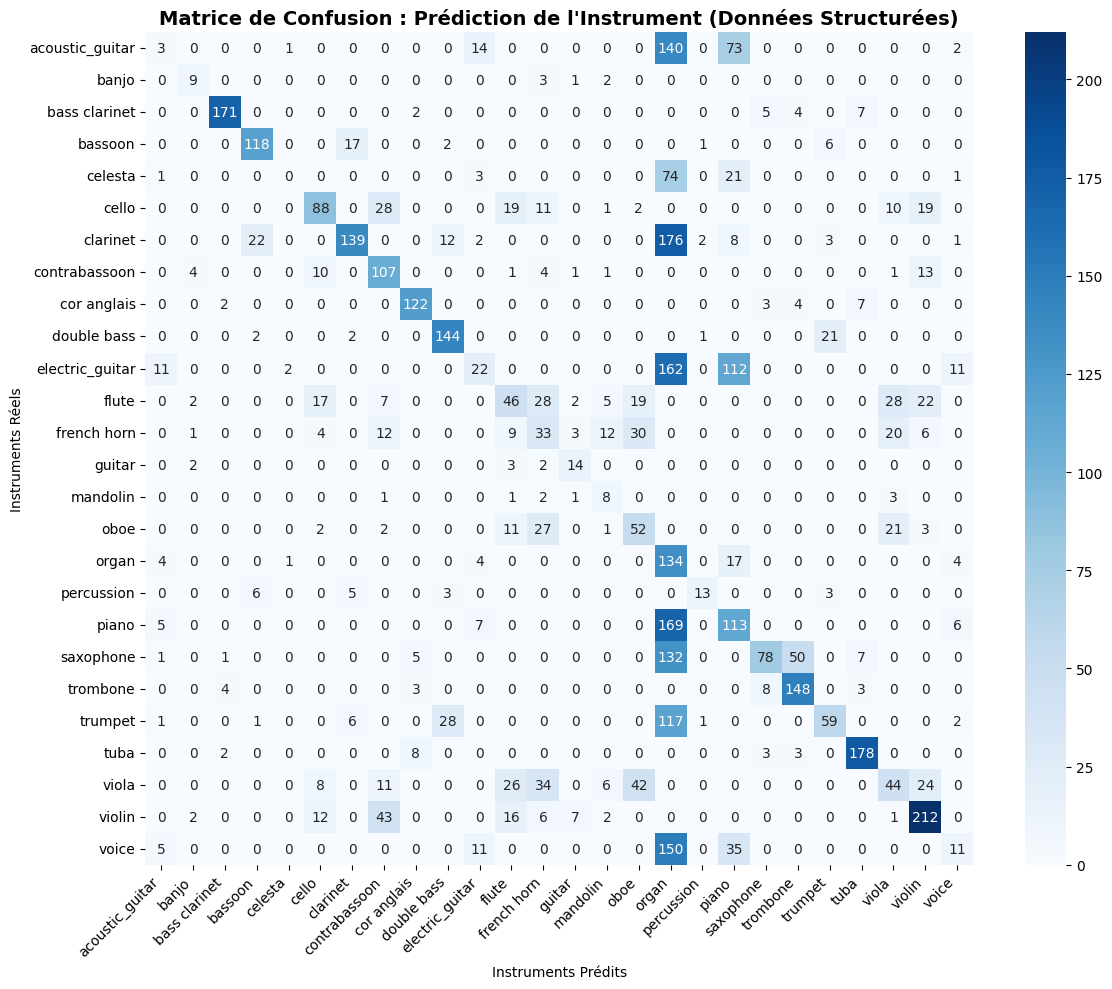

In [9]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred, labels=model_pipeline.classes_)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=model_pipeline.classes_, 
    yticklabels=model_pipeline.classes_
)

plt.title("Matrice de Confusion : Prédiction de l'Instrument (Données Structurées)", fontsize=14, fontweight='bold')
plt.xlabel("Instruments Prédits")
plt.ylabel("Instruments Réels")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# 1. On crée un DataFrame temporaire avec les vrais instruments et les prédictions
df_analyse = pd.DataFrame({
    'Instrument_Réel': y_test,
    'Prediction_Correcte': (y_test == y_pred)
})

# 2. On remplace les True/False par des labels plus explicites
df_analyse['Prediction_Correcte'] = df_analyse['Prediction_Correcte'].map({
    True: 'Bonne Prédiction (True)', 
    False: 'Mauvaise Prédiction (False)'
})

# 3. On génère le tableau croisé avec les totaux (margins=True)
tableau_bilan = pd.crosstab(
    df_analyse['Instrument_Réel'], 
    df_analyse['Prediction_Correcte'], 
    margins=True, 
    margins_name="Total"
)

# Affichage du tableau
print("=== BILAN DES PRÉDICTIONS PAR INSTRUMENT ===")
print(tableau_bilan)

=== BILAN DES PRÉDICTIONS PAR INSTRUMENT ===
Prediction_Correcte  Bonne Prédiction (True)  Mauvaise Prédiction (False)  \
Instrument_Réel                                                             
acoustic_guitar                            3                          230   
banjo                                      9                            6   
bass clarinet                            171                           18   
bassoon                                  118                           26   
celesta                                    0                          100   
cello                                     88                           90   
clarinet                                 139                          226   
contrabassoon                            107                           35   
cor anglais                              122                           16   
double bass                              144                           26   
electric_guitar                